RAVDESS files found: 1440

1. RAVDESS DATASET ANALYSIS (Sanity Check)

Total RAVDESS files: 1440

Emotion distribution:
emotion
Angry        192
Calm         192
Disgust      192
Fearful      192
Happy        192
Neutral       96
Sad          192
Surprised    192
Name: count, dtype: int64

Gender distribution:
gender
Male      720
Female    720
Name: count, dtype: int64


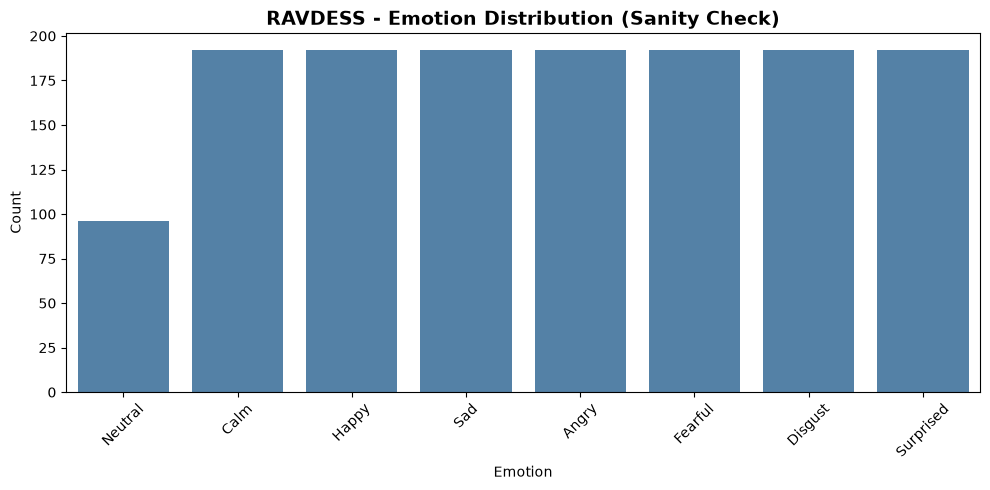

C:\Users\Lynne\AppData\Local\Temp\ipykernel_28320\1973735952.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ravdess_df, x="gender", palette="Set2")


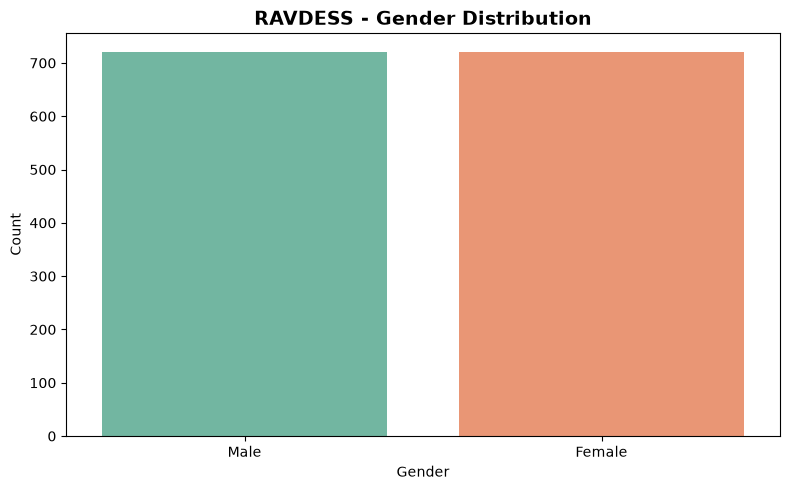


2. YOUR VOICE DATASET ANALYSIS

Total your voice files: 8

Emotion distribution:
emotion
Unknown    8
Name: count, dtype: int64

Gender distribution:
gender
Female    8
Name: count, dtype: int64


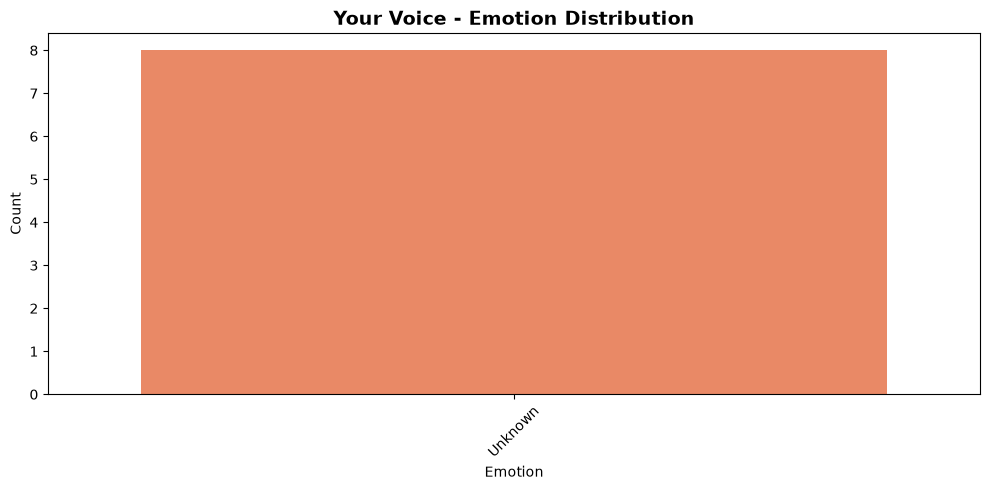

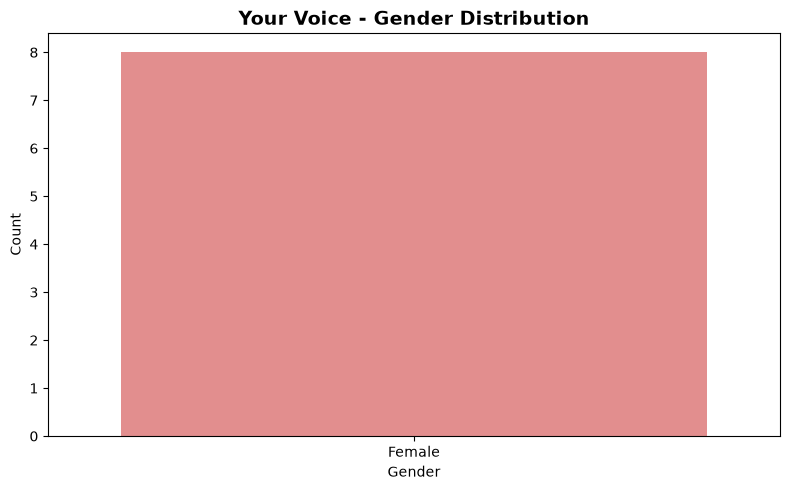


3. COMBINED DATASET ANALYSIS (RAVDESS + Your Voice)

Total files: 1448
  - RAVDESS: 1440
  - Your voice: 8

Emotion distribution:
emotion
Angry        192
Calm         192
Disgust      192
Fearful      192
Happy        192
Neutral       96
Sad          192
Surprised    192
Unknown        8
Name: count, dtype: int64

Gender distribution:
gender
Female    728
Male      720
Name: count, dtype: int64

COMPARISON: RAVDESS vs Your Voice Dataset

1. SIZE:
   - RAVDESS: 1440 recordings
   - Your voice: 8 recordings
   - Ratio: Your data is 0.6% of RAVDESS size

2. EMOTION BALANCE:
   RAVDESS emotions per category:
     - Angry: 192
     - Calm: 192
     - Disgust: 192
     - Fearful: 192
     - Happy: 192
     - Neutral: 96
     - Sad: 192
     - Surprised: 192

   Your voice emotions:
     - Unknown: 8

3. GENDER DISTRIBUTION:
   - RAVDESS: {'Male': 720, 'Female': 720}
   - Your voice: ALL FEMALE (only 1 speaker)
   - Combined: {'Female': 728, 'Male': 720}

4. KEY DIFFERENCES:
   - RAVDESS: 

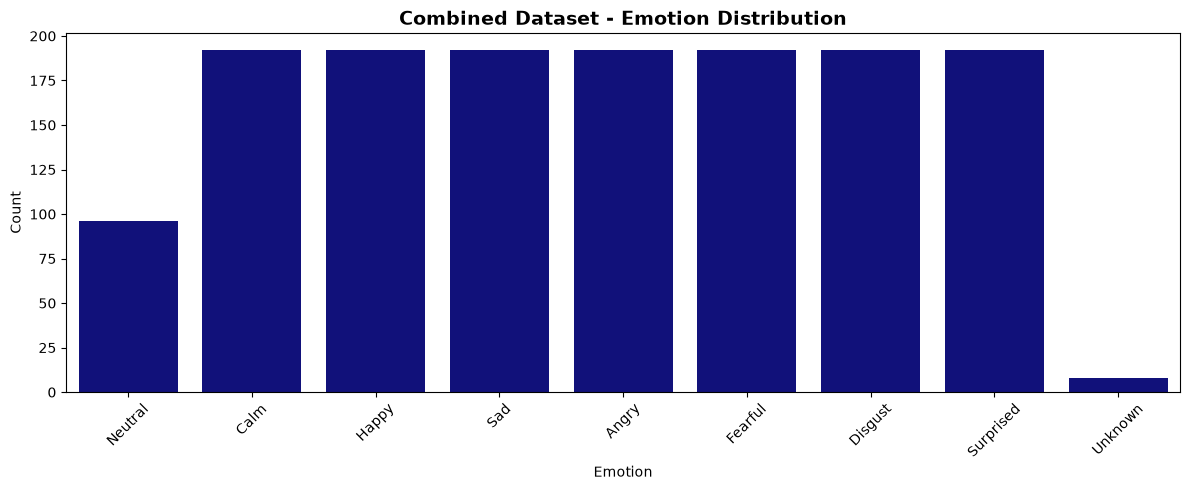

C:\Users\Lynne\AppData\Local\Temp\ipykernel_28320\1973735952.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_df, x="gender", palette="husl")


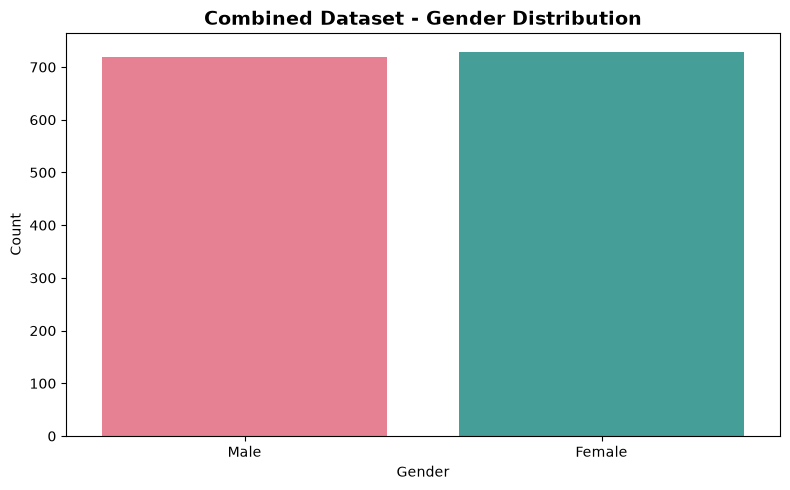

<Figure size 1200x600 with 0 Axes>

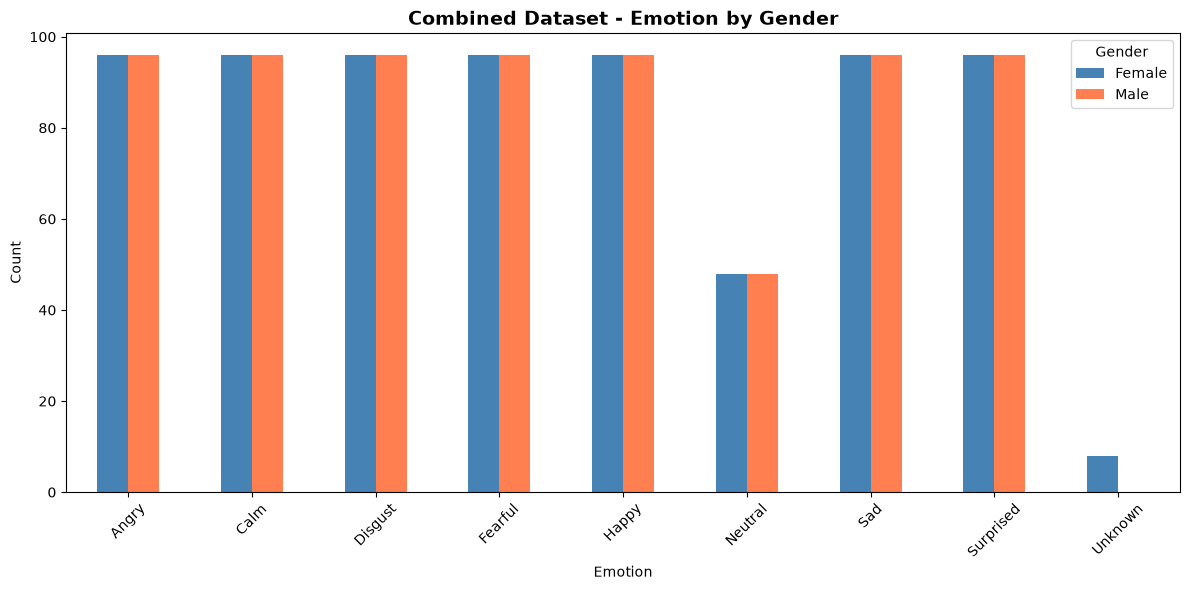


✓ Analysis complete!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_dir = r"C:\Users\Lynne\Week2-DataPreprocessing\data"

# ===== 1. LOAD RAVDESS DATASET =====
ravdess_dir = os.path.join(data_dir, "ravdess")
ravdess_files = []

for root, folders, files in os.walk(ravdess_dir):
    for file in files:
        if file.lower().endswith(".wav"):
            ravdess_files.append(os.path.join(root, file))

print(f"RAVDESS files found: {len(ravdess_files)}\n")

# Parse RAVDESS filenames
# Format: Modality-Vocal Channel-Emotion-Emotional Intensity-Statement-Repetition-Actor
# Example: 01-01-03-01-01-01-01.wav
ravdess_data = []

for file_path in ravdess_files:
    filename = os.path.basename(file_path).replace(".wav", "")
    parts = filename.split("-")
    
    if len(parts) < 7:
        continue
    
    try:
        emotion_code = int(parts[2])
        actor_id = int(parts[6])
    except (ValueError, IndexError):
        continue
    
    emotion_map = {
        1: "Neutral", 2: "Calm", 3: "Happy", 4: "Sad",
        5: "Angry", 6: "Fearful", 7: "Disgust", 8: "Surprised"
    }
    
    emotion = emotion_map.get(emotion_code, "Unknown")
    gender = "Male" if actor_id % 2 == 1 else "Female"
    
    ravdess_data.append({
        "file": file_path,
        "emotion": emotion,
        "gender": gender,
        "actor_id": actor_id
    })

ravdess_df = pd.DataFrame(ravdess_data)

print("="*60)
print("1. RAVDESS DATASET ANALYSIS (Sanity Check)")
print("="*60)
print(f"\nTotal RAVDESS files: {len(ravdess_df)}")
print("\nEmotion distribution:")
ravdess_emotion = ravdess_df["emotion"].value_counts().sort_index()
print(ravdess_emotion)
print("\nGender distribution:")
ravdess_gender = ravdess_df["gender"].value_counts()
print(ravdess_gender)

# Plot RAVDESS emotions
plt.figure(figsize=(10, 5))
sns.countplot(
    data=ravdess_df,
    x="emotion",
    order=["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"],
    color="steelblue"
)
plt.title("RAVDESS - Emotion Distribution (Sanity Check)", fontsize=14, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot RAVDESS gender
plt.figure(figsize=(8, 5))
sns.countplot(data=ravdess_df, x="gender", palette="Set2")
plt.title("RAVDESS - Gender Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ===== 2. LOAD YOUR VOICE DATASET =====
my_recordings_dir = os.path.join(data_dir, "MY_RECORDINGS")
my_voice_files = []

for root, folders, files in os.walk(my_recordings_dir):
    for file in files:
        if file.lower().endswith(".wav"):
            my_voice_files.append(os.path.join(root, file))

print("\n" + "="*60)
print("2. YOUR VOICE DATASET ANALYSIS")
print("="*60)
print(f"\nTotal your voice files: {len(my_voice_files)}")

my_voice_data = []

for file_path in my_voice_files:
    filename = os.path.basename(file_path).lower()
    
    emotion = "Unknown"
    
    if "happy" in filename:
        emotion = "Happy"
    elif "sad" in filename:
        emotion = "Sad"
    elif "angry" in filename:
        emotion = "Angry"
    elif "neutral" in filename:
        emotion = "Neutral"
    elif "calm" in filename:
        emotion = "Calm"
    elif "fearful" in filename or "fear" in filename:
        emotion = "Fearful"
    elif "disgust" in filename:
        emotion = "Disgust"
    elif "surprised" in filename or "surprise" in filename:
        emotion = "Surprised"
    
    my_voice_data.append({
        "file": file_path,
        "emotion": emotion,
        "gender": "Female"
    })

my_voice_df = pd.DataFrame(my_voice_data)

print("\nEmotion distribution:")
my_voice_emotion = my_voice_df["emotion"].value_counts().sort_index()
print(my_voice_emotion)
print("\nGender distribution:")
my_voice_gender = my_voice_df["gender"].value_counts()
print(my_voice_gender)

# Plot your voice emotions
plt.figure(figsize=(10, 5))
emotion_order = [e for e in ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised", "Unknown"] 
                 if e in my_voice_df["emotion"].values]
sns.countplot(
    data=my_voice_df,
    x="emotion",
    order=emotion_order,
    color="coral"
)
plt.title("Your Voice - Emotion Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot your voice gender
plt.figure(figsize=(8, 5))
sns.countplot(data=my_voice_df, x="gender", color="lightcoral")
plt.title("Your Voice - Gender Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ===== 3. COMBINED DATASET ANALYSIS =====
combined_df = pd.concat([ravdess_df, my_voice_df], ignore_index=True)

print("\n" + "="*60)
print("3. COMBINED DATASET ANALYSIS (RAVDESS + Your Voice)")
print("="*60)
print(f"\nTotal files: {len(combined_df)}")
print(f"  - RAVDESS: {len(ravdess_df)}")
print(f"  - Your voice: {len(my_voice_df)}")

print("\nEmotion distribution:")
combined_emotion = combined_df["emotion"].value_counts().sort_index()
print(combined_emotion)

print("\nGender distribution:")
combined_gender = combined_df["gender"].value_counts()
print(combined_gender)

# ===== DIFFERENCES BETWEEN DATASETS =====
print("\n" + "="*60)
print("COMPARISON: RAVDESS vs Your Voice Dataset")
print("="*60)

print("\n1. SIZE:")
print(f"   - RAVDESS: {len(ravdess_df)} recordings")
print(f"   - Your voice: {len(my_voice_df)} recordings")
print(f"   - Ratio: Your data is {len(my_voice_df)/len(ravdess_df)*100:.1f}% of RAVDESS size")

print("\n2. EMOTION BALANCE:")
print("   RAVDESS emotions per category:")
for emotion in ravdess_emotion.index:
    print(f"     - {emotion}: {ravdess_emotion[emotion]}")
print("\n   Your voice emotions:")
for emotion in my_voice_emotion.index:
    print(f"     - {emotion}: {my_voice_emotion[emotion]}")

print("\n3. GENDER DISTRIBUTION:")
print(f"   - RAVDESS: {ravdess_gender.to_dict()}")
print(f"   - Your voice: ALL FEMALE (only 1 speaker)")
print(f"   - Combined: {combined_gender.to_dict()}")

print("\n4. KEY DIFFERENCES:")
print("   - RAVDESS: Professional actors, balanced across 8 emotions, mix of genders")
print("   - Your voice: Single speaker (you), female, varying emotion representation")
print("   - Combined: Larger dataset but heavily skewed toward RAVDESS")

# ===== COMBINED VISUALIZATIONS =====
print("\n" + "="*60)
print("COMBINED DATASET VISUALIZATIONS")
print("="*60)

# Emotion in combined dataset
plt.figure(figsize=(12, 5))
emotion_order = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised", "Unknown"]
emotion_order = [e for e in emotion_order if e in combined_df["emotion"].values]
sns.countplot(
    data=combined_df,
    x="emotion",
    order=emotion_order,
    color="darkblue"
)
plt.title("Combined Dataset - Emotion Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gender in combined dataset
plt.figure(figsize=(8, 5))
sns.countplot(data=combined_df, x="gender", palette="husl")
plt.title("Combined Dataset - Gender Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Emotion by Gender (stacked)
plt.figure(figsize=(12, 6))
emotion_gender = pd.crosstab(combined_df["emotion"], combined_df["gender"])
emotion_gender.plot(kind="bar", stacked=False, figsize=(12, 6), color=["steelblue", "coral"])
plt.title("Combined Dataset - Emotion by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")